**Group information**

| Family name | First name | Email address |
| ----------- | ---------- | ------------- |
| Fernández            | Pablo          | pablo.fernandeza@bse.eu              |

# Semantic segmentation - Homework

## 1. Instructions

This tutorial explores how to automatically extract building footprints from aerial images. The objective is to perform semantic segmentation, or approximate the function that maps input images to class probabilities for each pixel. For this assignment, we use the U-Net convolutional network architecture [(Ronneberger et al. 2015)](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28). The GPU implementation of PyTorch is recommended.

The image dataset consists of 3347 colour images, each with dimensions $3 \times 256 \times 256$, sourced from [Minh (2013)](http://www.cs.toronto.edu/~vmnih/data/). Each image corresponds to a 300-square-metre area within the state of Massachusetts. The labels are building footprint vectors derived from [OpenStreetMap](https://www.openstreetmap.org/relation/61315), which have been rasterised into binary masks matching the spatial extent and resolution of the input images. For efficient storage, images and labels are saved in the JPEG format.

![U-Net model](https://www.dropbox.com/scl/fi/wgvqiix6scbm1c983ephk/segmentation_model.jpg?rlkey=71blfq7cm1yzw26puu4l0ybhs&dl=1)

## 2. Utilities

### 2.1. Libraries and device setup

In [1]:
# Packages

# Utilities
import os
import shutil
import tqdm
from urllib import request
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


# Deep learning
import torch
from torch import nn, optim, utils
from torchmetrics import classification
from torchvision import io, ops

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)
print(f'Using device: {device}')

# Utilities
classes = {0:'non-building', 255:'building'}

Using device: cuda


### 2.2. Functions

In [2]:
# Utilities
def download_data():
    if os.getcwd().endswith('/data'):
        print('Data folder already exists')
    else:
        request.urlretrieve('https://www.dropbox.com/scl/fo/90urs56ftly5r28jk18i4/AB2AIFdymQmeEqJZ8Og0V4Q?rlkey=nkb2w0fmfuym7sbgqpqnvm9cd&dl=1', 'data.zip')
        shutil.unpack_archive('data.zip', 'data')
        os.remove('data.zip')
        os.chdir('data')

def display_image(image:torch.Tensor, title:str='', cmap:str='gray', figsize=(4, 4)) -> None:
    image   = torch.einsum('dhw -> hwd', image)
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close()

### 2.3. Downloading the data

In [25]:
# download_data()

### 2.4. Set path to data folder

In [2]:
data_path = '/home/pablo/Documents/BSE-DSDM/3-Applications_of_DL/data_hw1/'

## 3. Questions

### 1)

1. Load the images and labels as `torch.Tensor` of dimensions $n \times d \times h \times w$. Normalise the images and labels between 0 and 1 and set the data type as `torch.float32`.

<small>Note: In the label images, pixel values of 0 indicate non-building areas, while 255 indicate buildings. Due to JPEG's lossy compression, some values may slightly differ from 0 or 255. You can round the pixel values to restore binary labels.</small>

First, we define a function that takes in the path of an image, reads it as a numpy array, offers the possibility of normalizing the images between 0 and 1 and then reads it as a torch file. Furthermore, for `label` files, they are rounded to either 0 or 255 (the closest value).

In [3]:
def read_image_numpy(file: str, dtype: torch.dtype, normalize: bool = True) -> np.ndarray:
    
    """
    Read a JPEG image file as a numpy array.
    
    Args:
        file (str): Path to the image file
        normalize (bool): Whether to normalize values to 0-1 range
        
    Returns:
        np.ndarray: Image array with shape [channels, height, width]
    """

    # Use torchvision's io.read_image and convert to numpy
    image = io.read_image(file).numpy()
    
    # For label images, round values to restore binary nature (for JPEG compression artifacts)
    if 'label' in file.lower():
        # Round to nearest of 0 or 255 - first find which value is closer
        image = np.where(image > 255/2, 255, 0)
    
    # Normalize the pixel values to 0-1 range if requested
    if normalize:
        image = image / 255.0
    
    image = torch.from_numpy(image).type(dtype)
    
    return image

Second, we read all of the images and labels as `torch.float32` files, and load them as a `torch.tensor` separately.

In [4]:
# Load data

# List all of the names of the images in the image folder (without the prefix)
files = [file.replace('image_', '') for file in os.listdir(os.path.join(data_path, 'images'))]

# Read images and labels and stack them into a single tensor
images = torch.stack([read_image_numpy(file = os.path.join(data_path, "images", f"image_{file}"), dtype=torch.float32, normalize=True) for file in files])
labels = torch.stack([read_image_numpy(file = os.path.join(data_path, "labels", f"label_{file}"), dtype = torch.float32, normalize=True) for file in files])

# Delete the files path list
del files

### 2)

2. Check the array dimensions and display several image–label pairs to ensure that they are correctly aligned.

#### Array dimensions

Checking the array dimensions.

In [6]:
print('Size of the image tensor:', images.size())
print('Size of the label tensor:', labels.size())

# Check if the number of images and labels are equal
if images.size(0) != labels.size(0):
    raise ValueError('Number of images and labels do not match!')

Size of the image tensor: torch.Size([3347, 3, 256, 256])
Size of the label tensor: torch.Size([3347, 1, 256, 256])


i.e., we have:
- $n$: 3,347 images and their corresponding labels.
- $d$: 3 color dimensions for the images, 1 for the labels (grayscale).
- $h$: both are 256 height (which is expected as they should match).
- $w$: both are 256 width (which is expected as they should match).

#### Display of image-label sample pairs

Displaying several image-label pairs (visual inspection to check alignment).

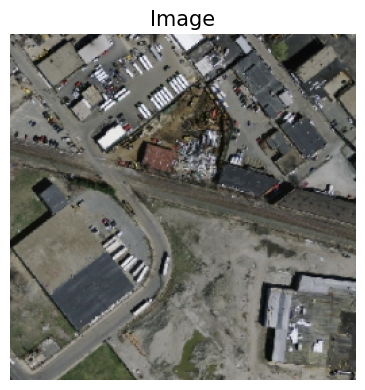

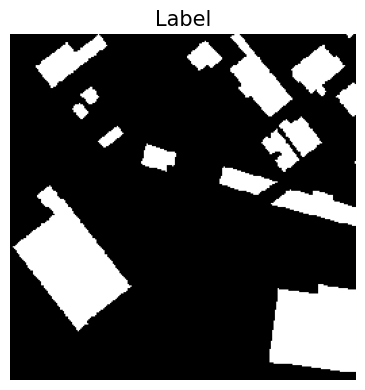

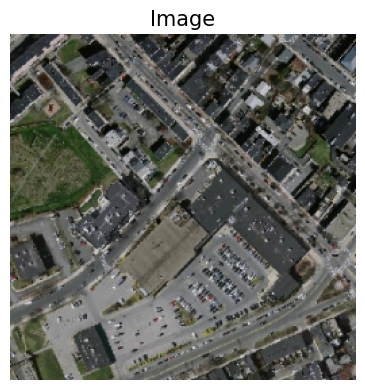

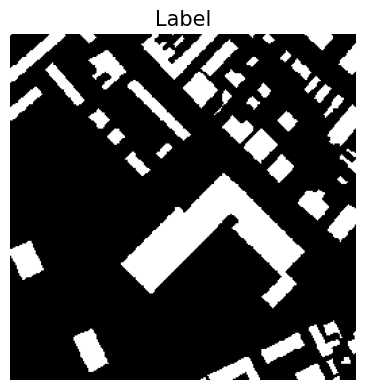

In [30]:
# Displays random images, labels and images
for i in torch.randint(0, len(images), (2,)):
  display_image(image = images[i], title = 'Image')
  display_image(image = labels[i], title = 'Label')

### 3)

3. Format the data as a `TensorDataset` and partition the observations into training (75%) and test (25%) samples. For each sample, create a `DataLoader` with a batch size suitable for your hardware (e.g. between 32 and 256).

<small>Note: Optionally, you can also include a validation sample by splitting the dataset into 70% training, 15% validation, and 15% test.</small>

Useful documentation: [`torch.utils.data`](https://pytorch.org/docs/stable/data.html)

In [5]:
# Format the data as a TensorDataset
dataset = utils.data.TensorDataset(images, labels)  # Create a TensorDataset from the image and label tensors
print(len(dataset))

3347


In [6]:
# Split the dataset into training, validation and test sets
train_dataset, val_dataset, test_dataset = utils.data.random_split(dataset, [0.7, 0.15, 0.15], generator=torch.Generator().manual_seed(42))

# Set batch size
batch_size = 64

# Set number of physical CPU cores (as int) to use for data loading
num_workers = os.cpu_count() // 2 if os.cpu_count() is not None else 0

# Create DataLoaders for each dataset
train_loader = utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,  # Shuffle the training data to prevent learning order bias, overfitting and improve generalization
    num_workers=num_workers,  # Use multiple workers for faster data loading
    pin_memory=True if device == 'cuda' else False,  # Pin memory for faster data transfer to GPU
)

val_loader = utils.data.DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,  # Keep validation data in the same order for consistent evaluation
    num_workers=num_workers,  # Use multiple workers for faster data loading
    pin_memory=True if device == 'cuda' else False,  # Pin memory for faster data transfer to GPU
)

test_loader = utils.data.DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,  # Keep test data in the same order for consistent evaluation
    num_workers=num_workers,  # Use multiple workers for faster data loading
    pin_memory=True if device == 'cuda' else False,  # Pin memory for faster data transfer to GPU
)

### 4)

4. Using PyTorch, define a simplified U-Net model with the number of filters indicated in the figure above (i.e. 8, 16, 32, 64, 128, ...). Choose the appropriate activation functions for the hidden layers and the output layer.

<small>Note: Optionally, you can include batch normalisation and spatial dropout layers to improve the model’s optimisation and generalisation, respectively.</small>

![U-Net model](https://www.dropbox.com/scl/fi/wgvqiix6scbm1c983ephk/segmentation_model.jpg?rlkey=71blfq7cm1yzw26puu4l0ybhs&dl=1)

The basic structure of this network is the following:

1. **Input**: a tensor of shape $(N, 3, H, W)$.
2. **Encode** down through five levels, doubling channels each time and halving spatial dimensions.
3. **Bottleneck**: deepest features at 128 channels.
4. **Decode** back up, halving channels and doubling spatial dimensions, while concatenating corresponding encoder features to preserve fine details.
5. **Output**: apply a 1×1 convolution → Sigmoid to produce a mask of shape $(N, 1, H, W)$ with values in (0,1).

All of the classes below initialize the parameters at each layer with `__init__` and then implement a `forward` method that defines the forward pass of the neural network, which "takes the input data and passes it through the layers of the network to produce the output. This method is executed whenever the model is called to make a prediction or to compute the loss during training" ([reference](https://discuss.pytorch.org/t/what-is-the-difference-init-and-forward-in-a-network-model/173907?utm_source=chatgpt.com)).

#### The double convolution

The two convolutional layers are included everywhere in the network, from the encoding to the decoding.

In [7]:
class DoubleConv(nn.Module):

    """
    A module that performs two consecutive 3x3 convolutions, each followed by Batch Normalization and ReLU activation.
    It also includes a spatial dropout layer to randomly drop out whole feature maps, which helps regularize the representations.
    """

    def __init__(self, in_ch, out_ch, dropout_p=0.1):
        super().__init__()
        self.double_conv = nn.Sequential(
            # 1st 3×3 conv → BatchNorm → ReLU
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            # 2nd 3×3 conv → BatchNorm → ReLU
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            # Spatial dropout to randomly drop out whole feature maps - regularizes the representations
            nn.Dropout2d(p=dropout_p)  # Spatial dropout with the proportion dropout_p
        )
    def forward(self, x):
        return self.double_conv(x)

Useful sources:
- [`Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d) - convolutional layer
- [`BatchNorm2d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html#torch.nn.BatchNorm2d) - normalization layer
- [`ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU) - non-linear activation function

#### The encoder module (`Down`)

The class below represents one encoding step.

In [8]:
class Down(nn.Module):

    """
    A module that performs a downsampling operation (by a factor of 2) using Max Pooling followed by a DoubleConv layer.
    """

    def __init__(self, in_ch, out_ch, dropout_p=0.1):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),             # Halves height (H) and width (W) of the input
            DoubleConv(in_ch, out_ch, dropout_p)
        )
    def forward(self, x):
        return self.pool_conv(x)

Useful sources:
- [`MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d) - pooling layer

#### The decoder module (`Up`)

This class represents one decoding step. It performs upsampling and concatenation with skip connection.

In [9]:
class Up(nn.Module):

    """
    A module that performs an upsampling operation (by a factor of 2) using either bilinear interpolation or transposed convolution,
    followed by a DoubleConv layer. It also concatenates the upsampled features with the corresponding skip connection from the encoder.
    """

    def __init__(self, in_ch, out_ch, dropout_p=0.1, bilinear=False):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch, dropout_p)
        else:
            self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
            # after upconv, channels=out_ch; concatenated with skip (also out_ch) → 2*out_ch
            self.conv = DoubleConv(out_ch * 2, out_ch, dropout_p)
    def forward(self, x, skip):

        x = self.up(x)               # upsample the coarse features

        # Pad if needed to match the encoder feature size
        # Sometimes the upsampled feature map might have a different spatial size
        # compared to the corresponding skip connection
        if x.size() != skip.size():
            diff_h = skip.size()[2] - x.size()[2]  # height difference
            diff_w = skip.size()[3] - x.size()[3]  # width difference
            # Pad the upsampled feature map to match the skip connection size
            x = nn.functional.pad(x, [diff_w // 2, diff_w - diff_w // 2, 
                                    diff_h // 2, diff_h - diff_h // 2])

        # Concatenate the upsampled features with the corresponding skip connection
        # along the channel dimension (dim=1)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

This class:

1. Upsamples via either bilinear interpolation or a learnable transposed convolution. See [`nn.Upsample`](https://pytorch.org/docs/stable/generated/torch.nn.Upsample.html#torch.nn.Upsample)
2. Pads if the resulting feature-map is off by 1 pixel in height/width. See [`nn.functional.pad`](https://pytorch.org/docs/stable/generated/torch.nn.functional.pad.html#torch.nn.functional.pad)
3. Concatenates with the corresponding encoder feature-map along the channel dimension (the “skip connection”). See [`torch.cat`](https://pytorch.org/docs/stable/generated/torch.cat.html)
4. Uses `DoubleConv` to fuse and refine these combined features.

#### Final 1 $\times$ 1 convolution

In [10]:
class OutConv(nn.Module):

    """
    A module that performs a 1x1 convolution to reduce the number of output channels to the number of classes.
    """

    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, n_classes, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

This convolution reduces the channels from whatever the last decoder output is (in the diagram, 8) down to the desired number of classes (1 for binary mask, as in this case - 0 for no building and 1 for building).

#### Putting all together in `UNet`

This class uses the constructions made above, and replicates the structure of the neural network in the diagram.

In [11]:
class UNet(nn.Module):

    """
    A U-Net architecture for image segmentation. It consists of an encoder path (downsampling) and a decoder path (upsampling),
    with skip connections between corresponding layers in the encoder and decoder paths.
    """

    def __init__(self, n_channels=3, n_classes=1, base_filters=8, dropout_p=0.1, bilinear=False):
        super().__init__()
        # define the encoder path
        self.inc   = DoubleConv(n_channels, base_filters, dropout_p)      # 3→8
        self.down1 = Down(base_filters,      base_filters*2, dropout_p)  # 8→16
        self.down2 = Down(base_filters*2,    base_filters*4, dropout_p)  # 16→32
        self.down3 = Down(base_filters*4,    base_filters*8, dropout_p)  # 32→64
        self.down4 = Down(base_filters*8,    base_filters*16, dropout_p) # 64→128 (bottleneck)

        # define the decoder path (mirrors encoder but in reverse)
        self.up1   = Up(base_filters*16, base_filters*8, dropout_p, bilinear) # 128→64
        self.up2   = Up(base_filters*8,  base_filters*4, dropout_p, bilinear) # 64→32
        self.up3   = Up(base_filters*4,  base_filters*2, dropout_p, bilinear) # 32→16
        self.up4   = Up(base_filters*2,  base_filters,   dropout_p, bilinear) # 16→8

        self.outc  = OutConv(base_filters, n_classes)  # 8→n_classes

        # Activation function for the output layer (only if loss compatible with probabilities)
        self.activation = nn.Sigmoid()  # final non-linearity for binary masks (convert logits to probabilities)
        # self.activation = nn.Softmax(dim=1)  # final non-linearity for multi-class masks (convert logits to probabilities)

    def forward(self, x):
        # ---- Encoder ----
        x1 = self.inc(x)      # 3→8 channels, full resolution
        x2 = self.down1(x1)   # 8→16 channels, 1/2ⁿ resolution
        x3 = self.down2(x2)   # 16→32
        x4 = self.down3(x3)   # 32→64
        x5 = self.down4(x4)   # 64→128 (bottleneck)

        # ---- Decoder with skip connections ----
        x  = self.up1(x5, x4) # decode 128→64, concat skip from x4
        x  = self.up2(x,  x3) # decode 64→32, concat skip from x3
        x  = self.up3(x,  x2) # decode 32→16, concat skip from x2
        x  = self.up4(x,  x1) # decode 16→8,  concat skip from x1

        logits = self.outc(x)        # 8→n_classes
        return logits  # Return logits (raw output of the network for compatibility with loss functions)
        # return self.activation(logits)  # apply final non-linearity (Sigmoid for binary or Softmax for multi-class)

Note that the output layer returns the logits, not probabilities, for compatibility with the loss function.

### 5)

5. Initialise the model and print its architecture. Select an appropriate optimisation algorithm and loss function.

<small>Note: To address class imbalance — since building pixels represent only a small fraction of the total — you can weight the loss function or use loss functions specifically designed for imbalance, such as [`torchvision.ops.sigmoid_focal_loss`](https://pytorch.org/vision/main/generated/torchvision.ops.sigmoid_focal_loss.html).</small>

#### Initializing the model

In [38]:
# Set the parameters for the U-Net model
n_channels = 3  # Number of input channels (RGB image)
n_classes = 1  # Number of output channels (1 for binary segmentation - building vs non-building)
base_filters = 8  # Number of filters in the first layer (check diagram)
dropout_p = 0.1  # Dropout probability for regularization
bilinear = False  # Use bilinear interpolation for upsampling (True) or transposed convolution (False)

# Initialize the model
model = UNet(
    n_channels=n_channels,
    n_classes=n_classes, 
    base_filters=base_filters,
    dropout_p=dropout_p,
    bilinear=bilinear
)
model = model.to(device)  # Move the model to the specified device (GPU or CPU)
print(model)

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Dropout2d(p=0.1, inplace=False)
    )
  )
  (down1): Down(
    (pool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1),

#### Loss function (addressing class imbalance)

In [ ]:
# Note that the images are already normalized to [0, 1] range

# Count pixels once, globally
n_pos = labels.sum()  # total “1” pixels
n_neg = labels.numel() - n_pos  # total “0” pixels
pos_weight = n_neg / (n_pos + 1e-6)  # avoid division by zero, inverse ratio of positive to negative pixels

# Print the number of positive and negative pixels
print(f'Number of positive pixels: {n_pos.item()}')
print(f'Number of negative pixels: {n_neg.item()}')
print(f'Ratio of positive to negative pixels: {n_pos.item() / n_neg.item()}')
print(f'Pos weight: {pos_weight.item()}')

# Create the loss function (BCEWithLogitsLoss for binary classification with logits)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

Number of positive pixels: 25226376.0
Number of negative pixels: 194122624.0
Ratio of positive to negative pixels: 0.12995072640270924
Pos weight: 7.695224285125732


We can see that non-building pixels are much more prevalent (only 13% of the total pixels in the labels correspond to buildings).

Through this weighting (see this [post](https://discuss.pytorch.org/t/pos-weight-and-weight-parameters-in-bcewithlogitsloss/130651?utm_source=chatgpt.com):

- If `pos_weight > 1`, positives get up-weighted.
- If `pos_weight < 1`, positives get down-weighted.

More information about the [`BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) class.

#### Optimization algorithm

In [40]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

References: [`torch.optim`](https://pytorch.org/docs/stable/optim.html)

### 6)

6. Write the PyTorch training routine and estimate the model parameters using the training sample.

<small>Note: If you use a validation sample, implement a validation routine and apply early stopping to prevent overfitting.<small>

#### Train-validation routine

[Basic guide](https://machinelearningmastery.com/creating-a-training-loop-for-pytorch-models/?utm_source=chatgpt.com) for creating a training loop.

This training routine includes:

1. Progress tracking with tqdm progress bars for both training and validation steps
2. Loss and IoU calculation for both training and validation sets. The IoU (Intersection over Union) metric is appropriate for segmentation tasks as it measures the overlap between the predicted segmentation and the ground truth.
3. Early stopping that monitors validation loss and stops training when no improvement is seen for a certain number of epochs
4. Best model saving that saves the model parameters (from the initialization in 5), weights with the lowest validation loss
5. Visualization of metrics to monitor the training process and check for overfitting

In [41]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10, delta=0.0001):
    """
    Train the model with early stopping based on validation loss.
    
    Args:
        model: The neural network model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        criterion: Loss function
        optimizer: Optimization algorithm
        num_epochs: Maximum number of training epochs
        patience: Number of epochs to wait for improvement before stopping
        delta: Minimum change in validation loss to qualify as improvement
        
    Returns:
        model: Trained model
        history: Dictionary containing training and validation metrics
    """
    
    ########################################
    # 1. Function setup and initialization
    ########################################

    # Initialize variables for early stopping
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_weights = None
    
    # For tracking metrics
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_metrics': [],
        'val_metrics': []
    }
    
    # Track total batches for progress display
    total_train_batches = len(train_loader)
    total_val_batches = len(val_loader)
    
    # Initialize metrics for IoU (Intersection over Union) calculation
    # - it calculates the overlap between the predicted and ground truth masks
    device = next(model.parameters()).device  # Get model's device
    iou_metric = classification.BinaryJaccardIndex().to(device)
    
    ########################################
    # 2. Training loop
    ########################################

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 50)
        
        ####################
        # 2.1. Training phase
        ####################

        model.train()  # Set model to training mode
        running_train_loss = 0.0
        running_train_iou = 0.0
        
        # Use tqdm for progress bar during training
        progress_bar = tqdm.tqdm(enumerate(train_loader), total=total_train_batches)
        for batch_idx, (inputs, labels) in progress_bar:
            # Move data to device
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            
            # Squeeze to match dimensions for loss calculation
            outputs = outputs.squeeze(1)  # From [B, 1, H, W] to [B, H, W]
            labels = labels.squeeze(1)    # From [B, 1, H, W] to [B, H, W]
            
            # Compute loss
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            # Update statistics
            running_train_loss += loss.item() * inputs.size(0)
            
            # Calculate IoU (convert outputs to binary predictions using 0.5 threshold)
            
            # Calculation of the IoU metric if the model outputs logits
            probs = torch.sigmoid(outputs)  # Conversion to probabilities - needed if the model outputs logits (comment otherwise)
            preds = (probs > 0.5).float()  # Now threshold the probabilities
            running_train_iou += iou_metric(preds, labels) * inputs.size(0)
            
            # Update progress bar
            progress_bar.set_description(f"Train Loss: {loss.item():.4f}")
        
        # Calculate epoch statistics
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_train_iou = running_train_iou / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)
        history['train_metrics'].append(epoch_train_iou)
        
        ####################
        # 2.2. Validation phase (no gradient computation, backpropagation or weight updates)
        ####################

        model.eval()  # Set model to evaluation mode
        running_val_loss = 0.0
        running_val_iou = 0.0
        
        # No gradient computation during validation
        with torch.no_grad():  # Disable gradient calculation
            progress_bar = tqdm.tqdm(enumerate(val_loader), total=total_val_batches)
            for batch_idx, (inputs, labels) in progress_bar:
                # Move data to device
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Forward pass
                outputs = model(inputs)
                
                # Squeeze to match dimensions
                outputs = outputs.squeeze(1)
                labels = labels.squeeze(1)
                
                # Compute loss
                loss = criterion(outputs, labels)
                
                # Update statistics
                running_val_loss += loss.item() * inputs.size(0)
                
                # Calculate IoU
                probs = torch.sigmoid(outputs)  # Conversion to probabilities - needed if the model outputs logits (comment otherwise)
                preds = (outputs > 0.5).float()
                running_val_iou += iou_metric(preds, labels) * inputs.size(0)
                
                # Update progress bar
                progress_bar.set_description(f"Val Loss: {loss.item():.4f}")
        
        # Calculate epoch statistics
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_iou = running_val_iou / len(val_loader.dataset)
        history['val_loss'].append(epoch_val_loss)
        history['val_metrics'].append(epoch_val_iou)
        
        # Print epoch statistics
        print(f"Training Loss: {epoch_train_loss:.4f}, IoU: {epoch_train_iou:.4f}")
        print(f"Validation Loss: {epoch_val_loss:.4f}, IoU: {epoch_val_iou:.4f}")
        
        ####################
        # 2.3. Early stopping check
        ####################

        # Check for improvement in validation loss
        if epoch_val_loss < best_val_loss - delta:
            print(f"Validation loss improved from {best_val_loss:.4f} to {epoch_val_loss:.4f}\n")
            best_val_loss = epoch_val_loss
            best_model_weights = model.state_dict().copy()
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f"No improvement in validation loss for {early_stop_counter} epochs\n")
            
            if early_stop_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs\n")
                break
    
    ########################################
    # 3. Final model loading: saving weights
    ########################################

    # Load best model weights
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(f"Loaded best model weights with validation loss: {best_val_loss:.4f}")

    return model, history, best_val_loss

#### Estimating the model weights

In [42]:
# Set training parameters
num_epochs = 50      # Maximum number of epochs to train
patience = 10        # Number of epochs with no improvement after which training will be stopped
delta = 0.0001       # Minimum change in validation loss to qualify as improvement

# Train the model
model, history, best_val_loss = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    patience=patience,
    delta=delta
)

Epoch 1/50
--------------------------------------------------


Val Loss: 1.1519: 100%|██████████| 8/8 [00:00<00:00, 10.62it/s]

Training Loss: 1.2457, IoU: 0.1181
Validation Loss: 1.1730, IoU: 0.1417
Validation loss improved from inf to 1.1730

Epoch 2/50
--------------------------------------------------



Val Loss: 1.0292: 100%|██████████| 8/8 [00:00<00:00, 10.11it/s]

Training Loss: 1.1364, IoU: 0.1441
Validation Loss: 1.0380, IoU: 0.2731
Validation loss improved from 1.1730 to 1.0380

Epoch 3/50
--------------------------------------------------


...

Training Loss: 0.6082, IoU: 0.3743
Validation Loss: 0.5785, IoU: 0.5367
Validation loss improved from 0.5867 to 0.5785

Epoch 49/50
--------------------------------------------------



Val Loss: 0.5614: 100%|██████████| 8/8 [00:00<00:00,  8.22it/s]

Training Loss: 0.6030, IoU: 0.3754
Validation Loss: 0.5790, IoU: 0.5196
No improvement in validation loss for 1 epochs

Epoch 50/50
--------------------------------------------------



Val Loss: 0.5809: 100%|██████████| 8/8 [00:00<00:00,  8.24it/s]


Training Loss: 0.6008, IoU: 0.3757
Validation Loss: 0.5782, IoU: 0.5419
Validation loss improved from 0.5785 to 0.5782

Loaded best model weights with validation loss: 0.5782


#### Saving the weights and the architecture after training

We define a function fitted to the previous code to load the model with the parameters that have been specified and the optimal weights.

In [43]:
# Save both model weights and architecture parameters
def save_model(model, filename, best_val_loss, **model_params):
    
    """Save model weights and architecture parameters"""
    
    try:

        save_dict = {
            'state_dict': model.state_dict(),  # model weights
            'model_params': model_params,  # model architecture parameters
            'best_val_loss': best_val_loss,  # best validation loss
        }
        model_path = os.path.join('models/', f'{filename}_val_loss_{best_val_loss:.4f}.pth')
        os.makedirs(os.path.dirname(model_path), exist_ok=True)  # Create directory if it doesn't exist
        torch.save(save_dict, model_path)
        print(f"Model saved to {model_path}")
    
    except Exception as e:
        print(f"Error saving model: {str(e)}")
        return None

In [ ]:
# Example usage after training
save_model(model, 
           'unet_segmentation_try3', 
           best_val_loss,
           # Model architecture parameters defined in section 5
           n_channels=n_channels, 
           n_classes=n_classes, 
           base_filters=base_filters,
           dropout_p=dropout_p,
           bilinear=bilinear)

Model saved to models/unet_segmentation_try3.pth_val_loss_0.5782.pth


#### Visualization of metrics

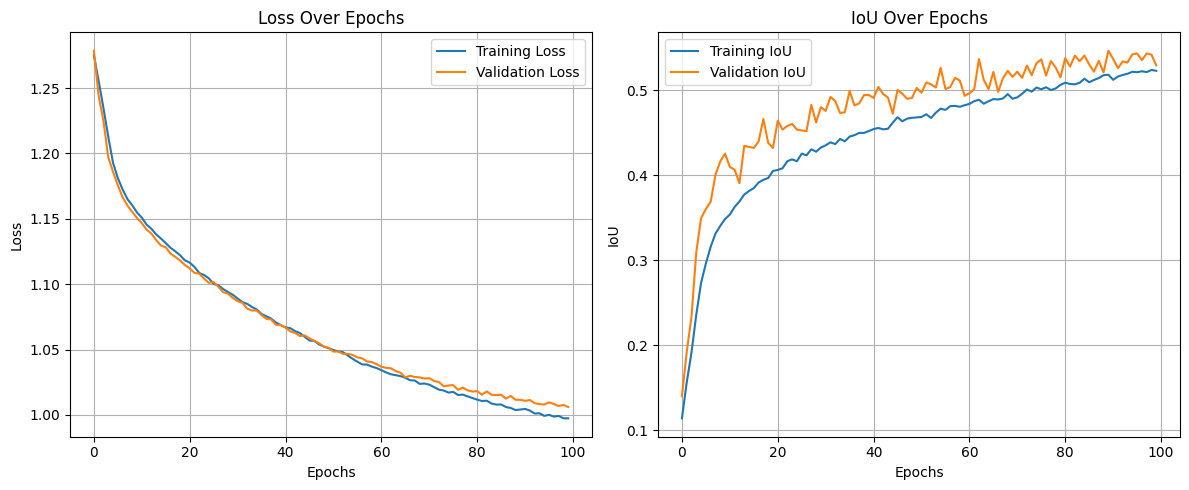

In [24]:
# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Convert GPU tensors to CPU for plotting (to avoid errors)
train_loss = [x.cpu().item() if torch.is_tensor(x) else x for x in history['train_loss']]
val_loss = [x.cpu().item() if torch.is_tensor(x) else x for x in history['val_loss']]
train_metrics = [x.cpu().item() if torch.is_tensor(x) else x for x in history['train_metrics']]
val_metrics = [x.cpu().item() if torch.is_tensor(x) else x for x in history['val_metrics']]

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot IoU
plt.subplot(1, 2, 2)
plt.plot(train_metrics, label='Training IoU')
plt.plot(val_metrics, label='Validation IoU')
plt.title('IoU Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

(This graph corresponds to another model training than the one finally used) Note that increasing the number of epochs further than 100 won't make a significant difference in this case - neither the loss nor the IoU will apparently decrease and increase significantly, respectively.

### 7)

7. Compute the predicted probabilities for the test images.

#### Loading a saved PyTorch model

To load a save model, we need to:
1. Initialize a new model with the same architecture
2. Load the state dictionary from the saved file (in the section "Estimating the model weights", this is done in the line `torch.save(model.state_dict(), [...])`)
3. Apply the state dictionary to the model

In [12]:
def load_model(filepath, device=None):

    """Load a model with its architecture parameters and weights. It returns the 
    loaded model in the specified or predetermined device (CPU or GPU). The model is created with the
    same parameters as the one used for training. The model weights are loaded from the
    saved state_dict.
    """ 

    # Check if a specific device is provided, otherwise use the default device
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    # Load the saved dictionary
    checkpoint = torch.load(filepath, map_location=device)
    
    # Extract the parameters and state dict
    model_params = checkpoint['model_params']
    state_dict = checkpoint['state_dict']
    
    # Create a new model with the saved parameters
    model = UNet(**model_params)
    
    # Load the weights
    model.load_state_dict(state_dict)
    model = model.to(device)
    
    print(f"Loaded model from {filepath} with parameters: {model_params}")
    if 'best_val_loss' in checkpoint:
        print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
        
    return model

In [13]:
# Example usage
model = load_model('models/unet_segmentation_try3_val_loss_0.5782.pth')

Loaded model from models/unet_segmentation_try3_val_loss_0.5782.pth with parameters: {'n_channels': 3, 'n_classes': 1, 'base_filters': 8, 'dropout_p': 0.1, 'bilinear': False}
Best validation loss: 0.5782


#### Predicting probabilities for test images

In [42]:
def predict(model, dataloader, device, return_probs=True, threshold=0.5):
    
    """
    Predict the output for a given dataloader using the provided model.
    
    Args:
        model: The trained model
        dataloader: DataLoader for the dataset to predict
        device: Device to perform the computation on (CPU or GPU)
        return_probs: Whether to return probabilities or binary predictions
        threshold: Threshold for binary predictions
        
    Returns:
        predictions: List of predictions (probabilities or binary masks)
        true_labels: List of true labels (if available in dataloader)
    """
    
    model.eval()  # Set model to evaluation mode (using it for inference)
    predictions = []
    true_labels = []
    
    with torch.no_grad():  # Disable gradient calculation (saves memory and computation)
        for inputs, labels in tqdm.tqdm(dataloader, desc="Generating predictions"):
            inputs = inputs.to(device)  # Move data to device
            
            # Forward pass
            logits = model(inputs)

            # Apply sigmoid to convert logits to probabilities
            probs = torch.sigmoid(logits.squeeze(1))
            
            if return_probs:
                # Return probabilities
                preds = probs
            else:
                # Return binary predictions
                preds = (probs > threshold).float()
            
            # Store predictions and true labels
            predictions.append(preds) 
            true_labels.append(labels.squeeze(1))
    
    # Concatenate batch predictions into a single tensor
    predictions = torch.cat(predictions, dim=0)
    true_labels = torch.cat(true_labels, dim=0)
    
    return predictions, true_labels

In [43]:
# Make predictions on the test set
test_predictions, test_labels = predict(
    model=model,
    dataloader=test_loader,
    device=device,
    return_probs=False,  # Get probabilities instead of binary predictions
    threshold=0.5  # Only used if return_probs=False
)

print(f"Predictions shape: {test_predictions.shape}")
print(f"Labels shape: {test_labels.shape}")

Generating predictions: 100%|██████████| 8/8 [00:01<00:00,  6.19it/s]


Predictions shape: torch.Size([502, 256, 256])
Labels shape: torch.Size([502, 256, 256])


#### Visualizing sample images and their predictions

In [44]:
def visualize_predictions(images, true_masks, pred_probs, num_samples=3, threshold=0.5):
    """
    Visualize input images, true masks, and predicted masks.
    
    Args:
        images: Tensor of input images [N, C, H, W]
        true_masks: Tensor of true masks [N, H, W]
        pred_probs: Tensor of predicted probabilities [N, H, W]
        num_samples: Number of random samples to visualize
        threshold: Threshold for converting probabilities to binary masks
    """
    # Get random indices
    indices = torch.randperm(len(images))[:num_samples]
    
    # Create binary predictions from probabilities
    pred_masks = (pred_probs > threshold).float()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for i, idx in enumerate(indices):
        # Get the image, true mask, and predicted mask
        img = images[idx].permute(1, 2, 0)  # CHW -> HWC for matplotlib
        true_mask = true_masks[idx]
        pred_mask = pred_masks[idx]
        
        # Plot input image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')
        
        # Plot true mask
        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title('True Mask')
        axes[i, 1].axis('off')
        
        # Plot predicted mask
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title(f'Predicted Mask (threshold={threshold})')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

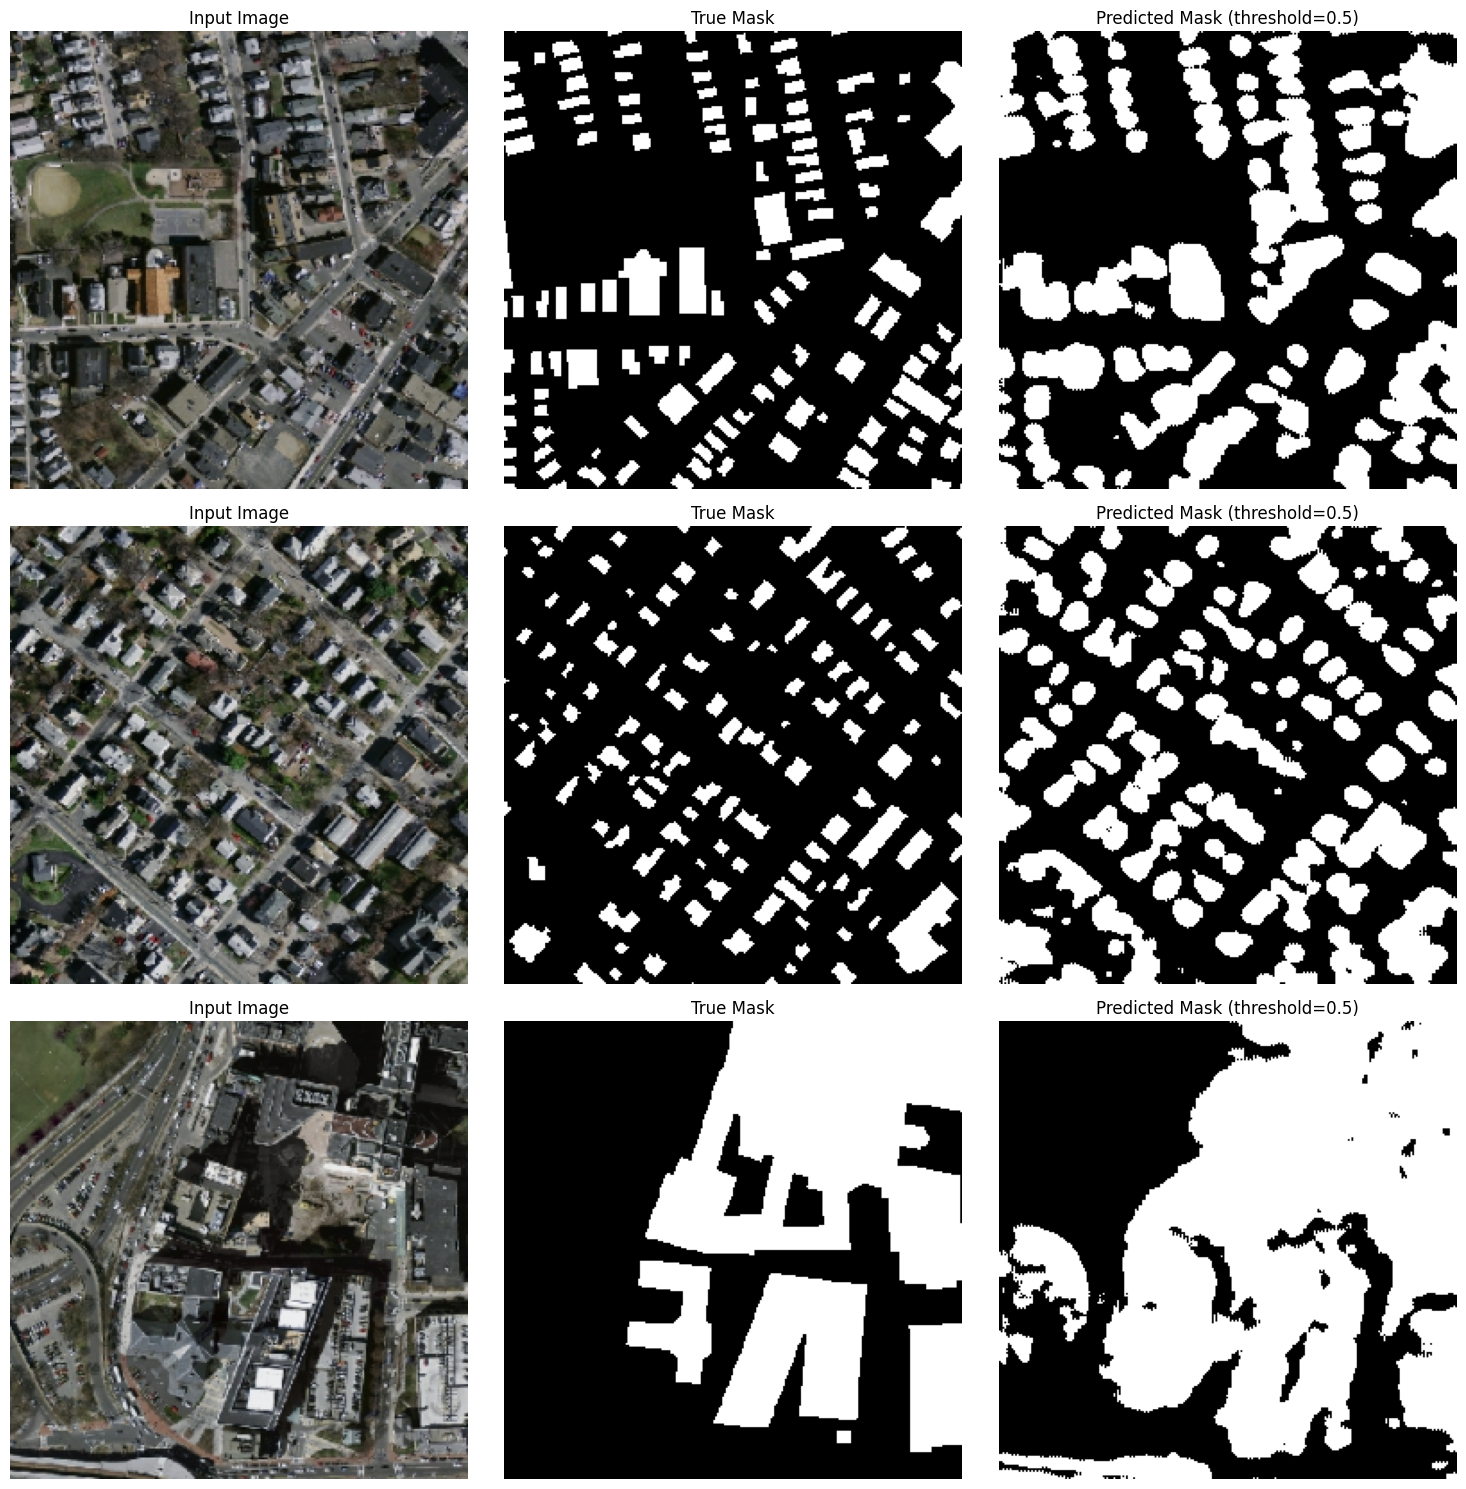

In [ ]:
# Get a batch of test images and their labels
test_images_sample = []
test_true_masks_sample = []

# Extract a few batches from the test loader
for images, labels in test_loader:
    test_images_sample.append(images)
    test_true_masks_sample.append(labels.squeeze(1))
    if len(test_images_sample) >= 3:  # Get 3 batches at most
        break

# Concatenate batches
test_images_sample = torch.cat(test_images_sample, dim=0)
test_true_masks_sample = torch.cat(test_true_masks_sample, dim=0)

# Make predictions (just for 3 batches)
with torch.no_grad():
    model.eval()
    test_pred_logits = model(test_images_sample.to(device)).squeeze(1).cpu()  # Apply sigmoid to convert logits to probabilities (comment if using sigmoid in the output activation function)
    test_pred_probs_sample = torch.sigmoid(test_pred_logits).cpu()
    # test_pred_probs_sample = model(test_images.to(device)).squeeze(1).cpu()  # Uncomment if using sigmoid in the output activation function

# Visualize
visualize_predictions(test_images_sample, test_true_masks_sample, test_pred_probs_sample, num_samples=3)

### 8)

8. Assess the model's generalisation performance by computing the confusion matrix, along with precision and recall metrics on the test sample. Comment on the results.

#### Confusion matrix

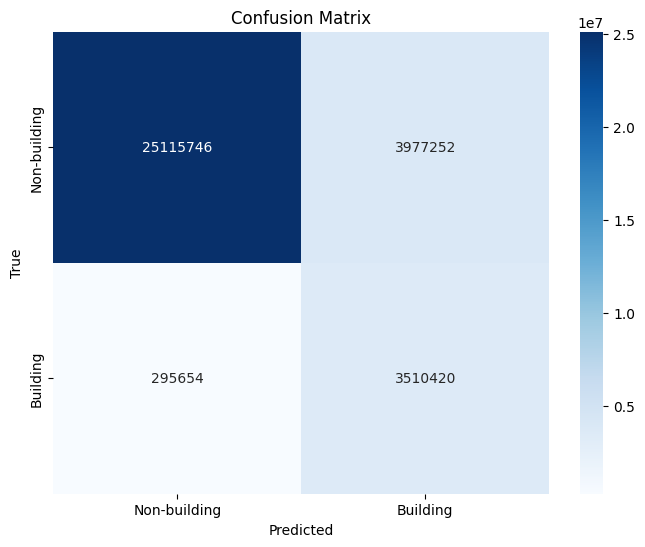

In [46]:
# Flatten the predictions and labels to 1D arrays for confusion matrix calculation
y_pred_flat = test_predictions.flatten()
y_true_flat = test_labels.flatten()

# Convert to numpy arrays if they're not already
if torch.is_tensor(y_pred_flat):
    y_pred_flat = y_pred_flat.cpu().numpy()
    y_true_flat = y_true_flat.cpu().numpy()

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_flat, y_pred_flat)

# Extract values from confusion matrix
tn, fp, fn, tp = conf_matrix.ravel()

# Visualization of confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-building', 'Building'],
            yticklabels=['Non-building', 'Building'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

From left to right and up to down:
- The first cell represents the **true negatives** (the objects that were not buildings and that were correctly predicted),
- The second cell represents the  **false positives** (the objects that were not buildings but that were predicted as buildings),
- The third cell represents the **false negatives** (actual buildings that were not predicted as such), and
- The fourth cell represents the **true positives** (buildings that were predicted as such).

#### Precision, recall and F1-score

Manual predictions using the outputs of the confusion matrix as inputs.

In [47]:
# Calculate precision and recall manually
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nManually calculated metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


Manually calculated metrics:
Precision: 0.4688
Recall: 0.9223
F1 Score: 0.6217


Robustness check with the `torchmetrics` library for computing the metrics.

In [48]:
# Initialize metrics
jaccard_metric = classification.BinaryJaccardIndex().to(device)
precision_metric = classification.BinaryPrecision().to(device)
recall_metric = classification.BinaryRecall().to(device)
f1_metric = classification.BinaryF1Score().to(device)

# Move tensors to the same device as the metrics to avoid errors
test_predictions_device = test_predictions.to(device)
test_labels_device = test_labels.to(device)

# Calculate metrics (make sure inputs are tensors)
iou_torch = jaccard_metric(test_predictions_device, test_labels_device)
precision_torch = precision_metric(test_predictions_device, test_labels_device)
recall_torch = recall_metric(test_predictions_device, test_labels_device)
f1_torch = f1_metric(test_predictions_device, test_labels_device)

print("\nTorchmetrics results:")
print(f"IoU: {iou_torch:.4f}")
print(f"Precision: {precision_torch:.4f}")
print(f"Recall: {recall_torch:.4f}")
print(f"F1 Score: {f1_torch:.4f}")


Torchmetrics results:
IoU: 0.4510
Precision: 0.4688
Recall: 0.9223
F1 Score: 0.6217


#### Full classification report

In [49]:
# Get detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_true_flat, y_pred_flat, 
                           target_names=['Non-building', 'Building']))


Classification Report:

              precision    recall  f1-score   support

Non-building       0.99      0.86      0.92  29092998
    Building       0.47      0.92      0.62   3806074

    accuracy                           0.87  32899072
   macro avg       0.73      0.89      0.77  32899072
weighted avg       0.93      0.87      0.89  32899072



#### Insights

- With the metrics computed above for a classification threshold of 0.5, we can observe that the recall is significantly higher than the precision. Since the recall represents the ratio of true positive predictions over all positive instances, this means that with a relatively low threshold of 0.5 we are mostly getting all of the positive instances (building predictions) right. In other words, wherever there are buildings, we are actually predicting that there is a building.
- Precision, on the other hand, tells a very different story: as the ratio of true positive predictions over all positive predictions, the model is showing signs of overpredicting building instances. In other words, the number of false positives is relatively high, which brings down the precision metric.
- These insights are also aligned with the full classification report: if we focus on the "building" class, we can observe the same comments that have been made about the trade-off that the model is making with a threshold of 0.5, which performs relatively well if we want to predict mostly all of the building pixels but quite badly for avoiding predicting buildings where there aren't.

### 9)

9. Implement a function to visualise true positives, true negatives, false positives, and false negatives as overlays on the input image.

In [50]:
def visualize_segmentation_errors(image, true_mask, pred_mask, threshold=0.5, figsize=(15, 10)):
    """
    Visualize segmentation errors with color-coded overlays:
    - True Positives (TP): Green - correctly identified buildings
    - True Negatives (TN): Black/transparent - correctly identified non-buildings
    - False Positives (FP): Red - non-buildings incorrectly identified as buildings
    - False Negatives (FN): Blue - buildings incorrectly identified as non-buildings
    
    Args:
        image: Input image tensor [C, H, W] or [H, W, C]
        true_mask: Ground truth mask tensor [H, W]
        pred_mask: Predicted mask tensor [H, W] or probability map to be thresholded
        threshold: Threshold for converting probabilities to binary predictions
        figsize: Figure size for the plot
    """
    # Handle tensors and convert to numpy
    if torch.is_tensor(pred_mask):
        pred_mask = pred_mask.detach().cpu().numpy()
    if torch.is_tensor(true_mask):
        true_mask = true_mask.detach().cpu().numpy()
    if torch.is_tensor(image):
        if image.dim() == 3 and image.size(0) == 3:  # [C, H, W] format
            image = image.permute(1, 2, 0).detach().cpu().numpy()
        else:
            image = image.detach().cpu().numpy()
    
    # Convert probability map to binary mask if needed
    if pred_mask.max() > 1.0:
        pred_mask = (torch.sigmoid(torch.tensor(pred_mask)) > threshold).numpy()
    elif np.max(pred_mask) <= 1.0 and not np.all(np.isin(pred_mask, [0, 1])):
        pred_mask = (pred_mask > threshold).astype(np.float32)
    
    # Ensure true_mask is binary
    if not np.all(np.isin(true_mask, [0, 1])):
        true_mask = (true_mask > 0.5).astype(np.float32)
    
    # Compute error categories
    true_positive = (pred_mask == 1) & (true_mask == 1)
    true_negative = (pred_mask == 0) & (true_mask == 0)
    false_positive = (pred_mask == 1) & (true_mask == 0)
    false_negative = (pred_mask == 0) & (true_mask == 1)
    
    # Create color-coded error visualization
    error_vis = np.zeros((*true_mask.shape, 3), dtype=np.float32)
    error_vis[true_positive] = [0, 1, 0]    # Green for TP
    error_vis[false_positive] = [1, 0, 0]   # Red for FP
    error_vis[false_negative] = [0, 0, 1]   # Blue for FN
    # TN is not highlighted (remains black)
    
    # Create blended visualization with original image
    alpha = 0.5  # Transparency for the overlay
    blended = image.copy()
    mask = np.any(error_vis > 0, axis=2)
    blended[mask] = alpha * error_vis[mask] + (1 - alpha) * image[mask]
    
    # Calculate error metrics for this specific image
    num_tp = np.sum(true_positive)
    num_tn = np.sum(true_negative)
    num_fp = np.sum(false_positive)
    num_fn = np.sum(false_negative)
    
    precision = num_tp / (num_tp + num_fp) if (num_tp + num_fp) > 0 else 0
    recall = num_tp / (num_tp + num_fn) if (num_tp + num_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    iou = num_tp / (num_tp + num_fp + num_fn) if (num_tp + num_fp + num_fn) > 0 else 0
    
    # Create the visualization
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Plot original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Input Image')
    axes[0, 0].axis('off')
    
    # Plot ground truth mask
    axes[0, 1].imshow(true_mask, cmap='gray')
    axes[0, 1].set_title('Ground Truth')
    axes[0, 1].axis('off')
    
    # Plot predicted mask
    axes[1, 0].imshow(pred_mask, cmap='gray')
    axes[1, 0].set_title(f'Prediction (threshold={threshold})')
    axes[1, 0].axis('off')
    
    # Plot error overlay on original image
    axes[1, 1].imshow(blended)
    axes[1, 1].set_title('Error Analysis')
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, color='green', label=f'True Positive: {num_tp}'),
        plt.Rectangle((0, 0), 1, 1, color='black', label=f'True Negative: {num_tn}'),
        plt.Rectangle((0, 0), 1, 1, color='red', label=f'False Positive: {num_fp}'),
        plt.Rectangle((0, 0), 1, 1, color='blue', label=f'False Negative: {num_fn}')
    ]
    axes[1, 1].legend(handles=legend_elements, loc='upper right', fontsize='small')
    axes[1, 1].axis('off')
    
    # Add metrics as text
    plt.figtext(0.5, 0.01, 
                f'Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | IoU: {iou:.4f}',
                ha='center', fontsize=12)
    
    plt.show()

    return {
        'tp': num_tp,
        'tn': num_tn,
        'fp': num_fp,
        'fn': num_fn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'iou': iou
    }

In [51]:
def visualize_multiple_samples(images, true_masks, pred_probs, num_samples=3, threshold=0.5):
    """
    Visualize segmentation errors for multiple random samples.
    
    Args:
        images: Tensor of input images [N, C, H, W]
        true_masks: Tensor of ground truth masks [N, H, W]
        pred_probs: Tensor of predicted probabilities [N, H, W]
        num_samples: Number of random samples to visualize
        threshold: Threshold for converting probabilities to binary masks
    """
    # Get random indices
    indices = torch.randperm(len(images))[:num_samples].tolist()
    
    # Visualize each sample
    metrics = []
    for idx in indices:
        img = images[idx]
        true_mask = true_masks[idx]
        pred_prob = pred_probs[idx]
        
        print(f"\nSample {idx}:")
        sample_metrics = visualize_segmentation_errors(img, true_mask, pred_prob, threshold)
        metrics.append(sample_metrics)
    
    # Print average metrics
    avg_metrics = {key: sum(m[key] for m in metrics)/len(metrics) for key in metrics[0] 
                  if key in ['precision', 'recall', 'f1', 'iou']}
    print("\nAverage metrics across samples:")
    for key, value in avg_metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")


Sample 154:


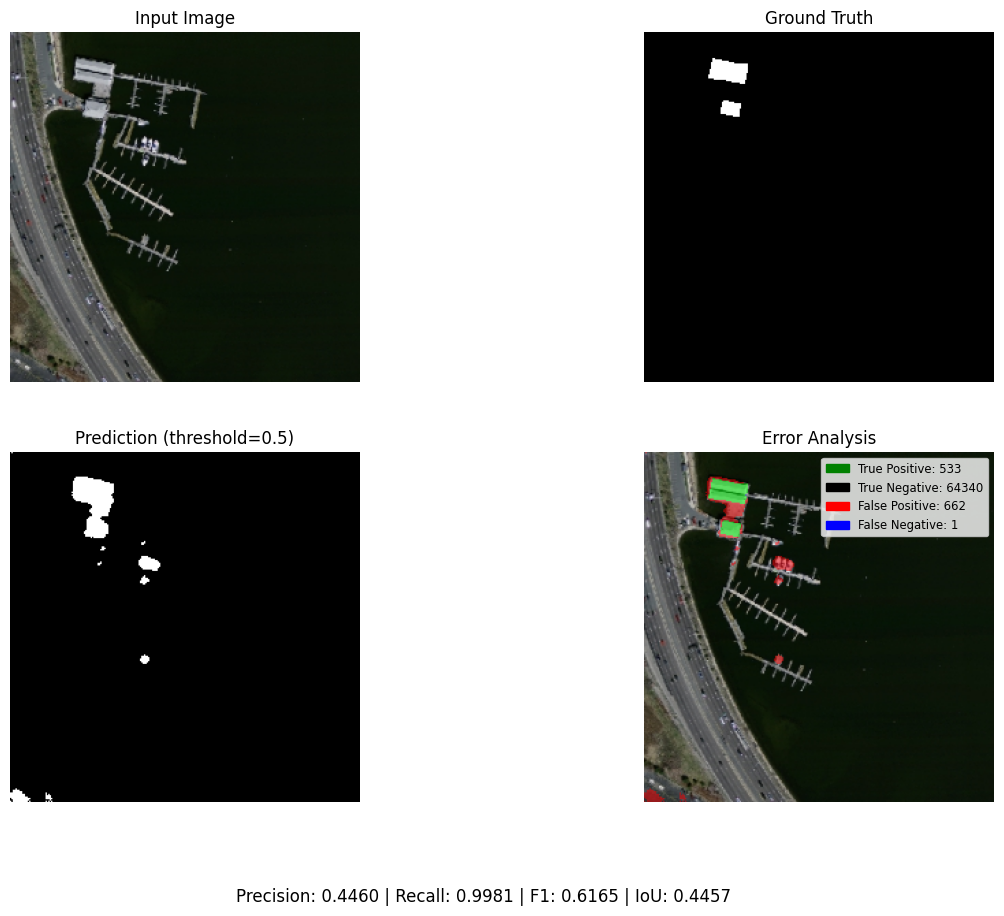


Sample 125:


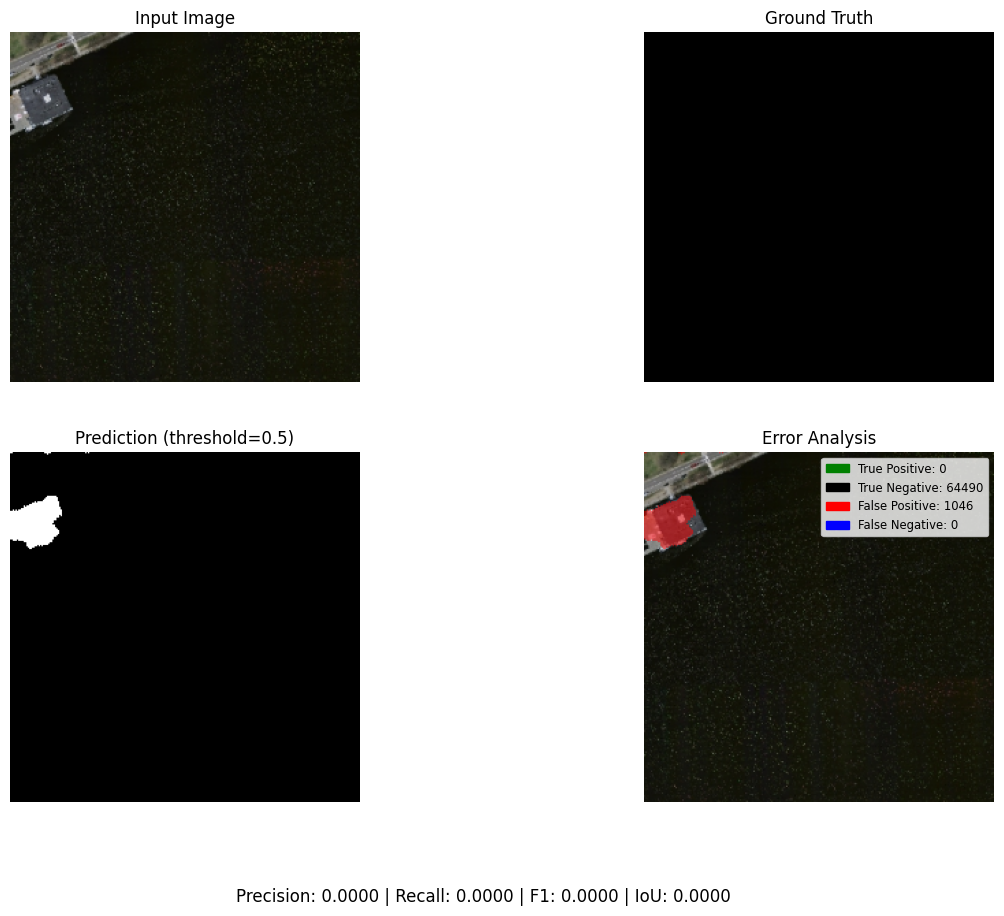


Sample 50:


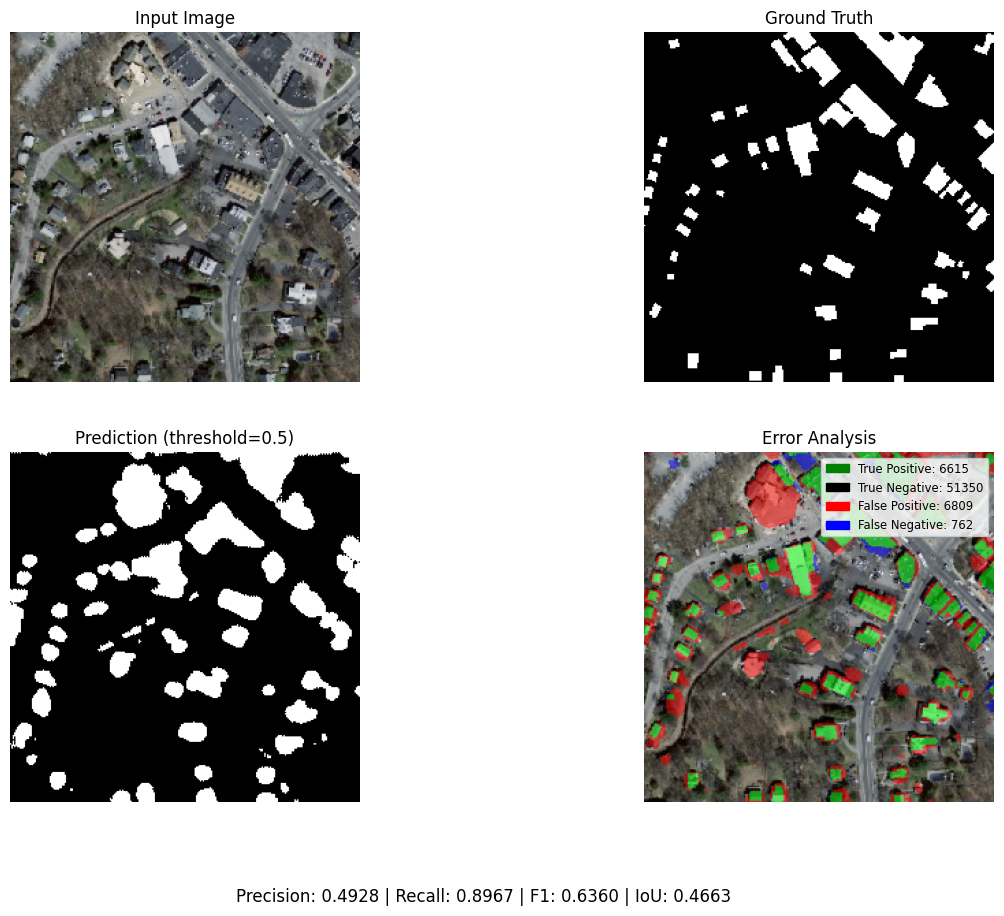


Average metrics across samples:
Precision: 0.3129
Recall: 0.6316
F1: 0.4175
Iou: 0.3040


In [52]:
# Visualize a few random samples
visualize_multiple_samples(
    test_images_sample,
    test_true_masks_sample,
    test_pred_probs_sample,
    num_samples=3,
    threshold=0.5
)

### 10)

10. Assuming that we give equal importance to reducing false positives and false negatives, use a decision probability threshold that strikes the best balance between these two quantities.

Since we want to give equal importance to reduce false positives (related to precision, as it is the ratio of positive instances correctly predicted over all positive predictions) and false negatives (related to recall, since it is the ratio of positive instances correctly predicted over all positive instances), **we should probably aim for a decision probability threshold which maximizes the F1-score, since it is the harmonic mean of precision and recall**, where:

$$F1-score = \frac{2\times Precision \times Recall}{Precision + Recall}$$

To do that, it can be useful to start by plotting the precision-recall curve for different probability thresholds (just to visualize the trade-off when changing the probability threshold), and then search for the probability threshold which maximizes the F1-score.

#### Precision-recall curve with F1-score for different probability thresholds

In [53]:
# First, we load the model
model = load_model('models/unet_segmentation_try3_val_loss_0.5782.pth')

# Second, we make the predictions on the test set with the probabilities
test_predictions_prob, test_labels = predict(
        model=model,
        dataloader=test_loader,
        device=device,
        return_probs=True  # Get probabilities instead of binary predictions
    )

Loaded model from models/unet_segmentation_try3_val_loss_0.5782.pth with parameters: {'n_channels': 3, 'n_classes': 1, 'base_filters': 8, 'dropout_p': 0.1, 'bilinear': False}
Best validation loss: 0.5782


Generating predictions: 100%|██████████| 8/8 [00:01<00:00,  6.25it/s]


In [79]:
# Third, we initialize the metrics and lists for storing the results
precision_metric = classification.BinaryPrecision().to(device)
recall_metric = classification.BinaryRecall().to(device)
f1_metric = classification.BinaryF1Score().to(device)

results = {
    'thresholds': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

# Fourth, we calculate the metrics for different thresholds 
for threshold in np.arange(0, 1.01, 0.005):

    # Move tensors to the same device as the metrics to avoid errors
    test_predictions_device = test_predictions_prob.to(device)
    test_labels_device = test_labels.to(device)

    # Convert probabilities to binary predictions using the threshold
    test_predictions_binary = (test_predictions_device > threshold).float()

    # Calculate metrics (make sure inputs are tensors)
    precision_torch = precision_metric(test_predictions_binary, test_labels_device)
    recall_torch = recall_metric(test_predictions_binary, test_labels_device)
    f1_torch = f1_metric(test_predictions_binary, test_labels_device)

    # Store the results
    results['thresholds'].append(threshold)
    results['precision'].append(precision_torch.item())
    results['recall'].append(recall_torch.item())
    results['f1_score'].append(f1_torch.item())

In [80]:
# Now, we convert the results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

results_df.head()

,thresholds,precision,recall,f1_score
0,0.000,0.115689,1.0,0.207386
1,0.005,0.115689,1.0,0.207386
2,0.010,0.115689,1.0,0.207386
3,0.015,0.115689,1.0,0.207386
4,0.020,0.115689,1.0,0.207386


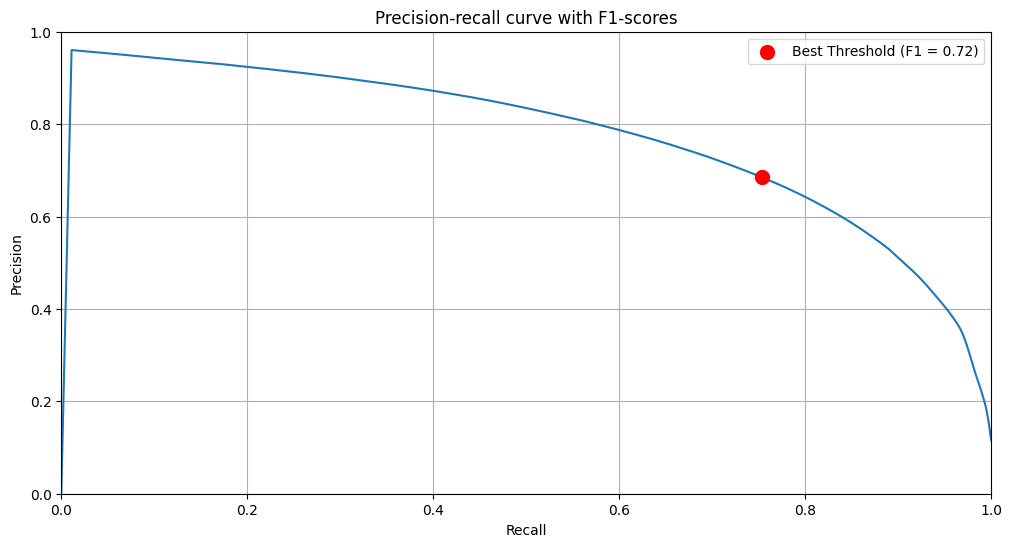

In [93]:
# Plot the 

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(results_df['recall'], results_df['precision'])
plt.title('Precision-recall curve with F1-scores')

# Add vertical and horizontal lines for precision and recall of maximum F1-score
max_f1_index = results_df['f1_score'].idxmax()
plt.scatter(results_df['recall'][max_f1_index], results_df['precision'][max_f1_index], 
            color='red', s=100, zorder=5, label=f'Best Threshold (F1 = {results_df['f1_score'][max_f1_index]:.2f})')

# Adjust scale of the axes
plt.xlim(0, 1)
plt.ylim(0, 1)

# Add grid, labels and legend
plt.grid()
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

plt.show()

- The beginning of the curve represents the highest probability thresholds possible, where (except for extremely high probability thresholds, where there seems to be few correct true positives) the precision is very high (as the number of false positives is very low).
- On the other hand, the end of the curve represents the lowest probability thresholds possible, where the recall converges to a high value (as the number of false negatives will be very low, as we will more easily classify an instance as positive).
- The precision converges, at the end of the curve, to the class imbalance proportion (of 13%, as shown in section 5), where we will classify all instances as positive. This happens because all the actual positives will be correctly predicted, but all the actual negatives will be incorrectly predicted.

In [74]:
# Print the best threshold in terms of the F1-score
print('Best threshold and metrics for the maximum F1-score:')
display(results_df.loc[results_df['f1_score'].idxmax()])

Best threshold and metrics for the maximum F1-score:


thresholds    0.750000
precision     0.698145
recall        0.736991
f1_score      0.717042
Name: 15, dtype: float64

#### Discussion

- In this case, the threshold that maximizes the F1-score to 71.7% is of 75% (i.e., if the predicted probability of having a building in a pixel is equal or above 75%, we will classify that pixel as "building", otherwise as "non-building").
- As shown in the precision-recall curve, this F1-score strikes a good balance between both metrics, which stay close to 70%.
- This balance is convenient in case that the decision-maker cares equally about avoiding false positives (precision) as false negatives (recall).